# A Validation Pipeline for a Hybrid Decision-Making Model

This notebook implements a full validation pipeline for a **Hybrid Discrete-Continuous Glaze Model**. Given the challenges of fitting complex models to limited real-world data, the primary goal here is to use a synthetic dataset to prove that our model and fitting procedures can accurately recover known ground-truth parameters.

The pipeline is structured as follows:

1.  **Model Definition**: We define the hybrid model, which combines discrete between-trial belief updates with continuous within-trial evidence accumulation.
2.  **Two-Step Optimization**: We define a robust fitting strategy that separates the fitting of the hazard rate (`H`) from the fitting of the continuous model parameters (`A_hat`, `K`, `sigma`, `T_nd`).
3.  **Parameter Recovery Pipeline**: We generate data from several "virtual subjects" with known parameters and run our optimization to see how well we can recover them.

# Section 0: Model Implementation 

Data found at: c:\Users\emart\Backup\Osnabruck\Jahre\3.Jahr\5.Semester\5. mldm\project\report\notebooks\data\evan.csv
Running Murphy Simulation...


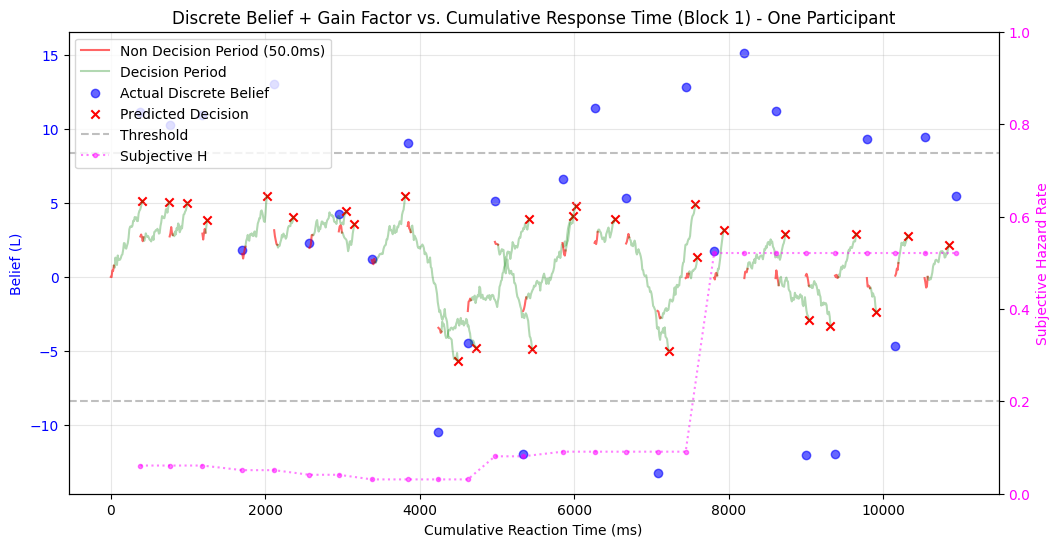

Processed Block 1: 27 trials


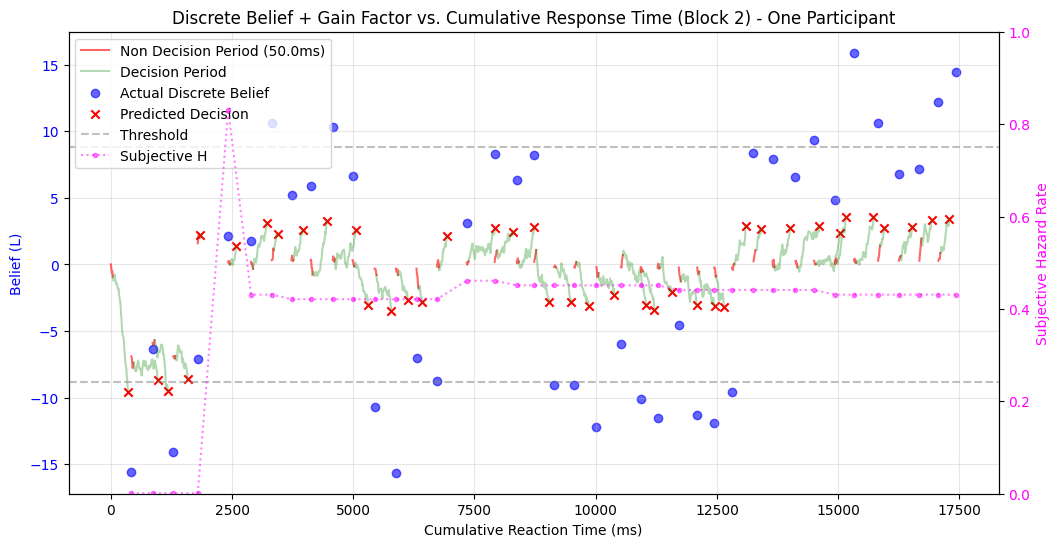

Processed Block 2: 40 trials


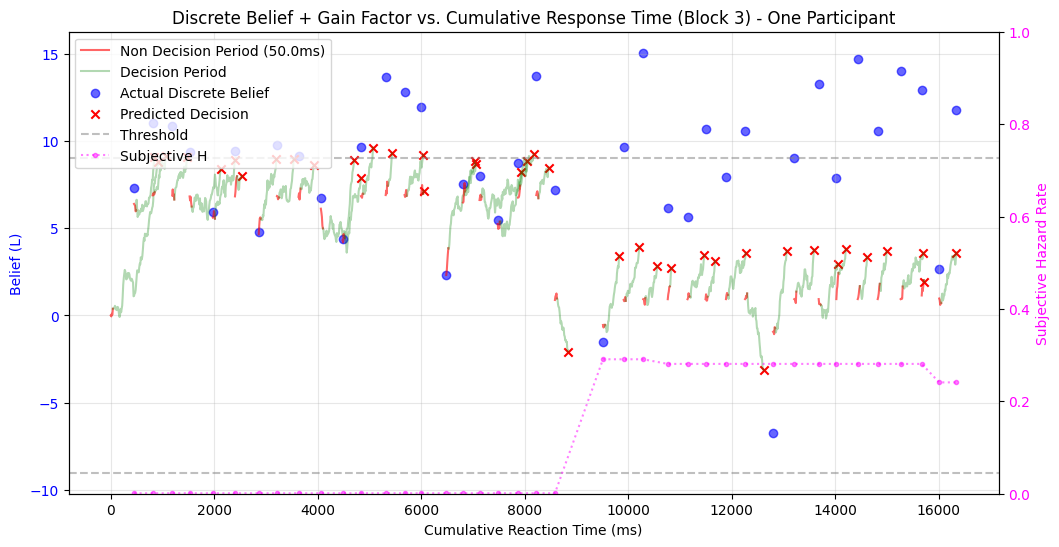

Processed Block 3: 40 trials


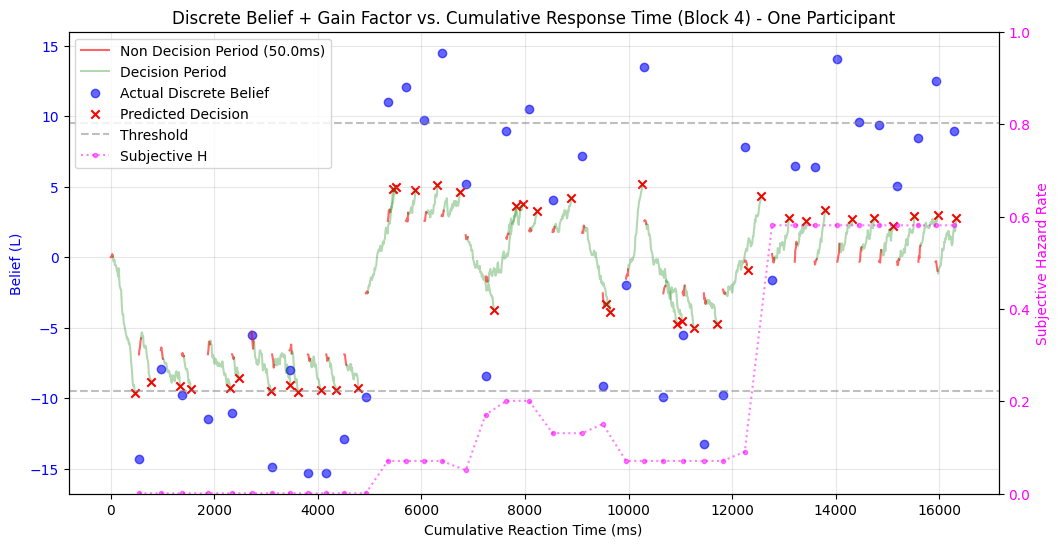

Processed Block 4: 40 trials


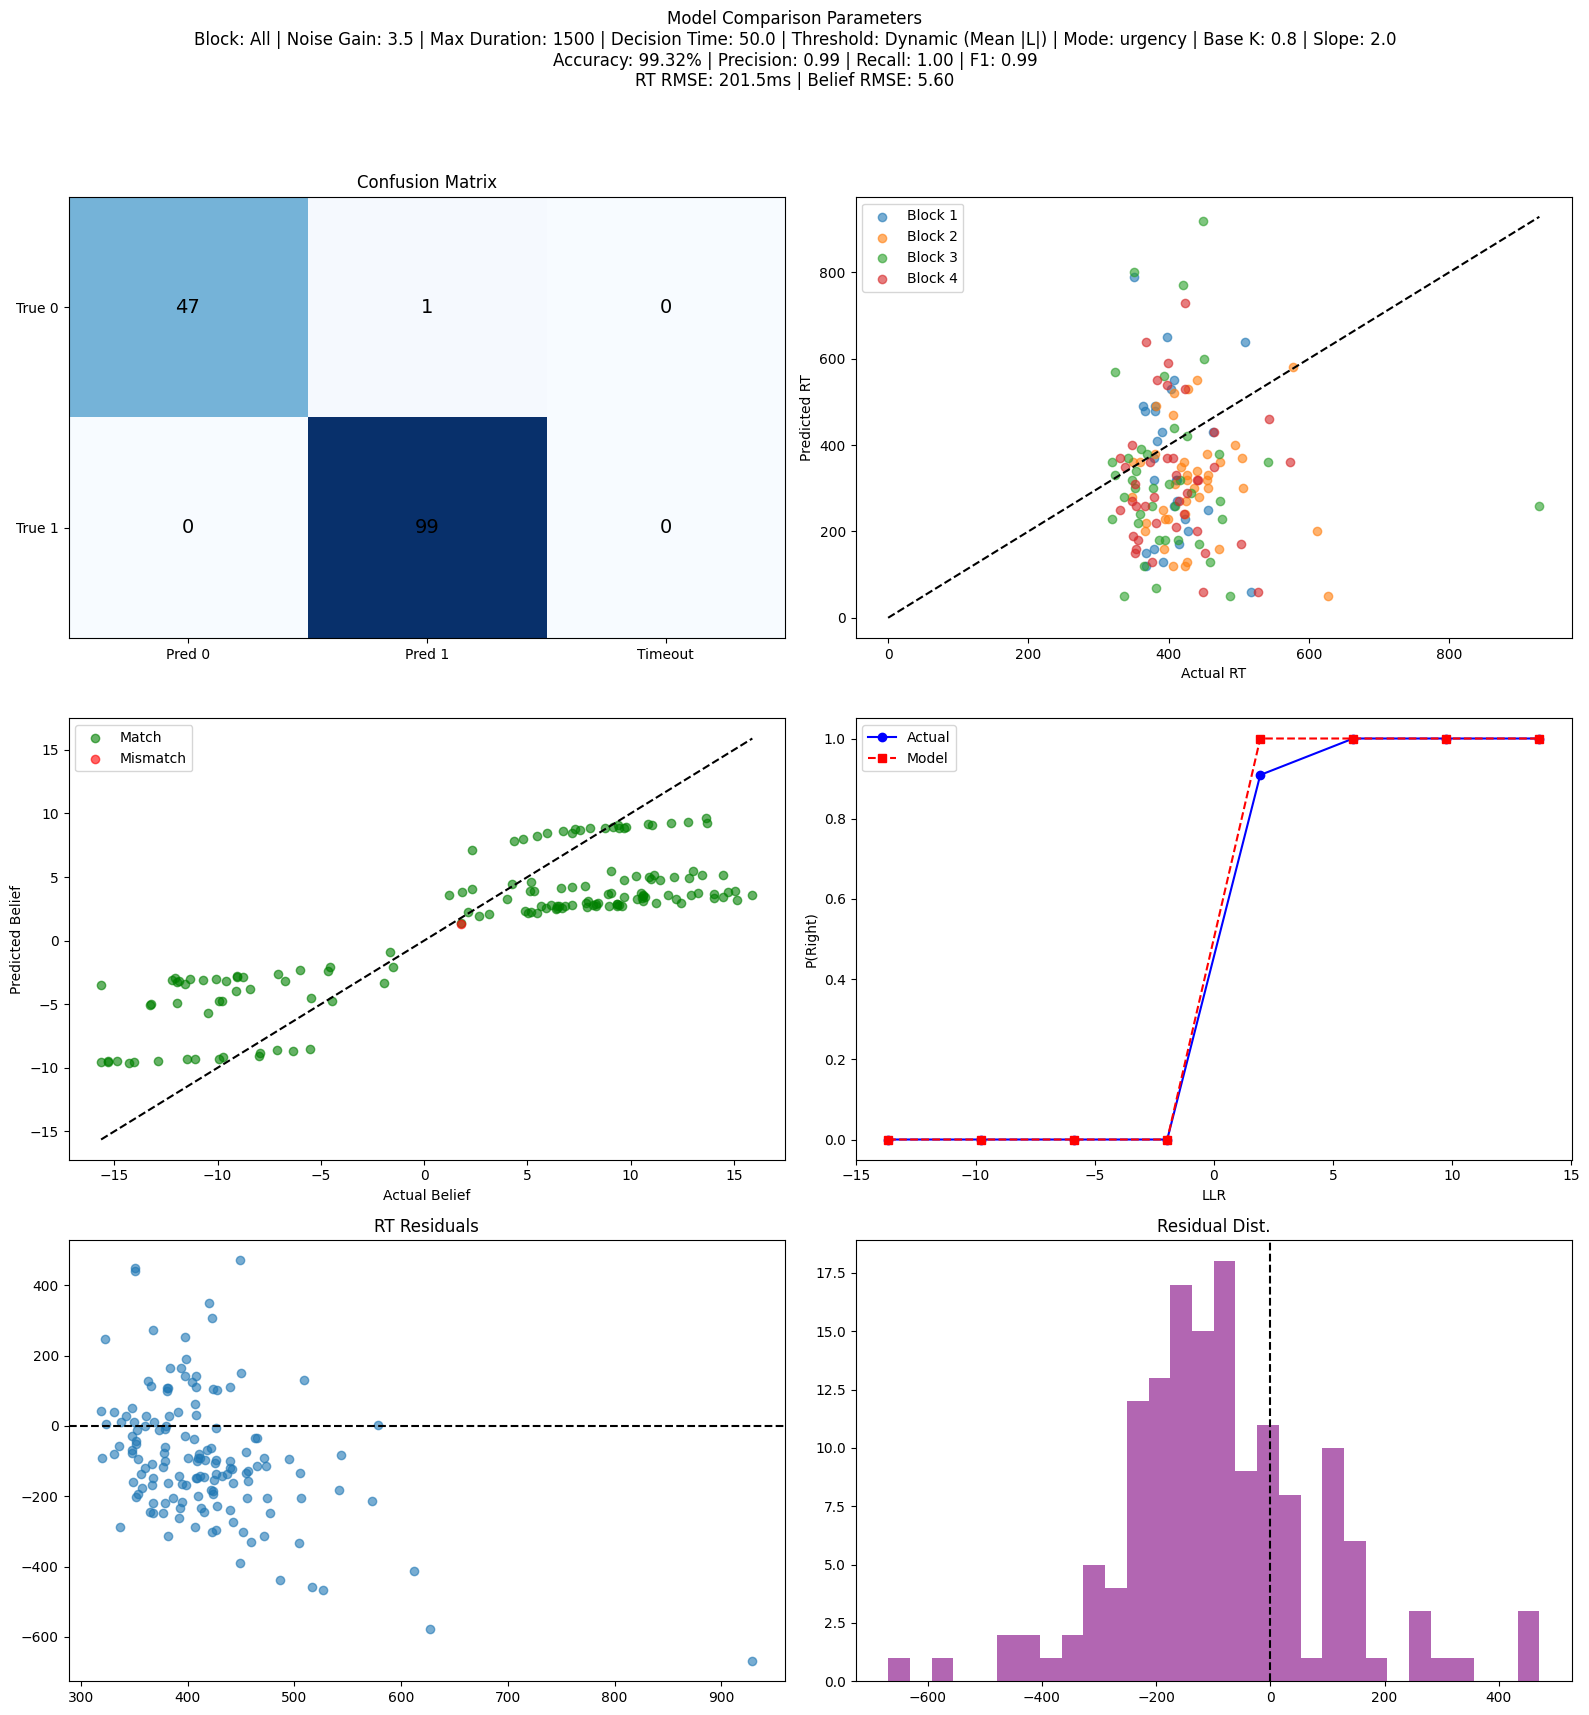

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def psi_function(L_prev, H):
    """
    Calculates the prior expectation (Psi) for the Glaze model.
    """
    if abs(L_prev) > 100:
        return np.sign(L_prev) * np.log((1 - H) / H)

    term1 = (1 - H) / H
    term_pos = term1 + np.exp(-L_prev)
    term_neg = term1 + np.exp(L_prev)

    return L_prev + np.log(term_pos) - np.log(term_neg)

def simulate_trial(
    prev_belief_L,
    current_LLR,
    H,
    belief_threshold,
    max_duration_ms,
    dt=0.01,
    noise_std=0.0,
    decision_time_ms=0.0,
    noise_gain=1.0,
    stop_on_sat=False,
    gain_K=1.0,
    gain_mode='fixed', 
    urgency_slope=0.0
):
    max_duration_sec = max_duration_ms / 1000.0

    # Determine initial gain base
    if gain_mode == 'weber':
        effective_K_base = gain_K / (1.0 + abs(current_LLR))
    else:
        effective_K_base = gain_K

    psi = psi_function(prev_belief_L, H)

    # estimate asymptotic boundary if saturation is enabled
    if stop_on_sat and H > 1e-9:
        scaled_input = effective_K_base * current_LLR
        asymptote = np.arcsinh(scaled_input / (2 * H))
        belief_threshold = abs(asymptote) * 0.999

    trajectory = [psi]
    time_points = [0.0]

    L_current = psi
    time_current = 0.0
    decision = 0

    while time_current < max_duration_sec:
        # Update gain based on temporal dynamics
        if gain_mode == 'urgency':
            current_K = gain_K + (urgency_slope * time_current)
        elif gain_mode == 'weber':
            current_K = effective_K_base
        else:
            current_K = gain_K

        # Glaze dynamics
        L_safe = np.clip(L_current, -10, 10)
        deterministic_change = -2 * H * np.sinh(L_safe) * dt
        drift = current_K * current_LLR * dt 
        diffusion = noise_gain * noise_std * np.sqrt(dt) * np.random.randn()

        L_current += deterministic_change + drift + diffusion
        L_current = np.clip(L_current, -100, 100)
        time_current += dt

        trajectory.append(L_current)
        time_points.append(time_current * 1000.0)

        # Threshold crossing check
        if abs(L_current) >= belief_threshold and (time_current * 1000.0) >= decision_time_ms:
            decision = np.sign(L_current)
            break

    return {
        'reaction_time_ms': time_current * 1000.0,
        'final_belief': L_current,
        'decision': decision,
        'trajectory': np.array(trajectory),
        'time_points_ms': np.array(time_points),
        'final_K': current_K if 'current_K' in locals() else gain_K
    }

def plot_model_comparison(df, params=None):
    plot_df = df.copy()
    y_true = plot_df['choice'].values.astype(int)
    y_pred_raw = plot_df['predicted_decision'].values
    y_pred_mapped = []
    agreement = []

    # Map predictions to agreement categories
    for t, p in zip(y_true, y_pred_raw):
        if p == 1: p_map = 1
        elif p == -1: p_map = 0
        else: p_map = 2 
        y_pred_mapped.append(p_map)
        
        if p_map == 2: 
            agreement.append('Timeout')
        elif t == p_map: 
            agreement.append('Match')
        else: 
            agreement.append('Mismatch')
    
    plot_df['agreement'] = agreement

    # Classification Metrics
    correct_mask = ((y_true == 1) & (y_pred_raw == 1)) | ((y_true == 0) & (y_pred_raw == -1))
    accuracy = np.mean(correct_mask)
    
    tp = np.sum((y_true == 1) & (y_pred_raw == 1))
    fp = np.sum((y_true == 0) & (y_pred_raw == 1))
    fn = np.sum((y_true == 1) & (y_pred_raw != 1))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics_str = f"Accuracy: {accuracy:.2%} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}"

    # Regression Metrics
    valid_rt = plot_df.dropna(subset=['predicted_rt_ms', 'reaction_time_ms'])
    rt_rmse = np.sqrt(np.mean((valid_rt['predicted_rt_ms'] - valid_rt['reaction_time_ms']) ** 2)) if not valid_rt.empty else np.nan

    valid_belief = plot_df.dropna(subset=['predicted_belief', 'belief_L'])
    belief_rmse = np.sqrt(np.mean((valid_belief['predicted_belief'] - valid_belief['belief_L']) ** 2)) if not valid_belief.empty else np.nan
    
    reg_metrics_str = f"RT RMSE: {rt_rmse:.1f}ms | Belief RMSE: {belief_rmse:.2f}"

    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    ax1, ax2 = axes[0]; ax3, ax4 = axes[1]; ax5, ax6 = axes[2]
    
    if params:
        param_str = " | ".join([f"{k}: {v}" for k, v in params.items()])
        fig.suptitle(f"Model Comparison Parameters\n{param_str}\n{metrics_str}\n{reg_metrics_str}", fontsize=12)
    else:
        fig.suptitle(f"Model Performance Metrics\n{metrics_str}\n{reg_metrics_str}", fontsize=12)
    
    # 1. Confusion Matrix
    conf_matrix = np.zeros((2, 3), dtype=int)
    for t, p in zip(y_true, y_pred_mapped): conf_matrix[t, p] += 1
    ax1.imshow(conf_matrix, cmap='Blues', aspect='auto')
    for i in range(2):
        for j in range(3):
            ax1.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='black', fontsize=14)
    ax1.set_xticks([0, 1, 2]); ax1.set_yticks([0, 1])
    ax1.set_xticklabels(['Pred 0', 'Pred 1', 'Timeout']); ax1.set_yticklabels(['True 0', 'True 1'])
    ax1.set_title('Confusion Matrix')

    # 2. RT Comparison
    unique_blocks = sorted(plot_df['block_id'].unique())
    cmap = plt.get_cmap('tab10')
    for i, block in enumerate(unique_blocks):
        subset = plot_df[plot_df['block_id'] == block]
        ax2.scatter(subset['reaction_time_ms'], subset['predicted_rt_ms'], color=cmap(i%10), label=f'Block {block}', alpha=0.6)
    
    max_rt = max(plot_df['reaction_time_ms'].max(), plot_df['predicted_rt_ms'].max())
    ax2.plot([0, max_rt], [0, max_rt], 'k--')
    ax2.set_xlabel('Actual RT'); ax2.set_ylabel('Predicted RT'); ax2.legend()

    # 3. Belief Comparison
    colors = {'Match': 'green', 'Mismatch': 'red', 'Timeout': 'gray'}
    for cat, color in colors.items():
        subset = plot_df[plot_df['agreement'] == cat]
        if not subset.empty: ax3.scatter(subset['belief_L'], subset['predicted_belief'], c=color, label=cat, alpha=0.6)
    
    min_b = min(plot_df['belief_L'].min(), plot_df['predicted_belief'].min())
    max_b = max(plot_df['belief_L'].max(), plot_df['predicted_belief'].max())
    ax3.plot([min_b, max_b], [min_b, max_b], 'k--')
    ax3.set_xlabel('Actual Belief'); ax3.set_ylabel('Predicted Belief'); ax3.legend()

    # 4. Psychometric Curve
    if not plot_df.empty:
        bins = np.linspace(plot_df['LLR'].min(), plot_df['LLR'].max(), 9)
        plot_df['llr_bin'] = pd.cut(plot_df['LLR'], bins)
        actual_probs = plot_df.groupby('llr_bin', observed=False)['choice'].mean()
        bin_centers = [(b.left + b.right)/2 for b in actual_probs.index]
        ax4.plot(bin_centers, actual_probs, 'o-', label='Actual', color='blue')
        
        pred_valid = plot_df[plot_df['predicted_decision'] != 0].copy()
        if not pred_valid.empty:
            pred_valid['pred_choice_mapped'] = (pred_valid['predicted_decision'] == 1).astype(int)
            pred_probs = pred_valid.groupby('llr_bin', observed=False)['pred_choice_mapped'].mean()
            ax4.plot(bin_centers, pred_probs, 's--', label='Model', color='red')
        ax4.legend(); ax4.set_xlabel('LLR'); ax4.set_ylabel('P(Right)')

    # 5. Residuals
    residuals = plot_df['predicted_rt_ms'] - plot_df['reaction_time_ms']
    ax5.scatter(plot_df['reaction_time_ms'], residuals, alpha=0.6); ax5.axhline(0, color='k', linestyle='--'); ax5.set_title('RT Residuals')
    ax6.hist(residuals, bins=30, color='purple', alpha=0.6); ax6.axvline(0, color='k', linestyle='--'); ax6.set_title('Residual Dist.')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) if params else plt.tight_layout()
    plt.show()

def run_simulation_and_plot(csv_path, block_id=None):
    df = pd.read_csv(csv_path)
    
    # Data type conversion
    df['reaction_time_ms'] = pd.to_numeric(df['reaction_time_ms'], errors='coerce')
    df['belief_L'] = pd.to_numeric(df['belief_L'], errors='coerce')
    df['LLR'] = pd.to_numeric(df['LLR'], errors='coerce')
    df['subjective_h_snapshot'] = pd.to_numeric(df['subjective_h_snapshot'], errors='coerce')
    df['choice'] = pd.to_numeric(df['choice'], errors='coerce').fillna(0).astype(int)

    # Simulation parameters (Murphy optimization)
    noise_std = 0.7  
    max_duration = 1500  
    decision_time_ms = 50.0 
    noise_gain = 3.5 

    df['cumulative_rt'] = df.groupby('block_id')['reaction_time_ms'].cumsum()

    # Urgency configuration
    gain_mode = 'urgency'
    gain_K_base = 0.8       
    urgency_slope = 2.0     

    if block_id is not None:
        blocks_to_process = [block_id]
    else:
        blocks_to_process = sorted(df['block_id'].unique())

    processed_blocks = []

    for b_id in blocks_to_process:
        block_df = df[df['block_id'] == b_id].copy()
        
        if block_df.empty:
            continue
            
        threshold = block_df['belief_L'].abs().mean()
        
        predicted_rts = []
        predicted_decisions = []
        predicted_beliefs = []
        
        prev_actual_belief = 0.0
        prev_actual_cumulative_rt = 0.0
        
        # Plot individual block
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        for i, row in block_df.iterrows():
            sim_result = simulate_trial(
                prev_belief_L=prev_actual_belief,
                current_LLR=row['LLR'],
                H=row['subjective_h_snapshot'],
                belief_threshold=threshold,
                max_duration_ms=max_duration,
                dt=0.01,
                noise_std=noise_std,
                decision_time_ms=decision_time_ms,
                noise_gain=noise_gain,
                stop_on_sat=True,
                gain_K=gain_K_base,
                gain_mode=gain_mode,       
                urgency_slope=urgency_slope 
            )
            
            # Prepare plotting data
            trajectory_times = sim_result['time_points_ms'] + prev_actual_cumulative_rt
            relative_times = sim_result['time_points_ms']
            trajectory_values = sim_result['trajectory']
            split_idx = np.searchsorted(relative_times, decision_time_ms)
            
            times_pre = trajectory_times[:split_idx]
            values_pre = trajectory_values[:split_idx]
            times_post = trajectory_times[max(0, split_idx-1):]
            values_post = trajectory_values[max(0, split_idx-1):]
            
            if len(times_pre) > 1:
                label_pre = f'Non Decision Period ({decision_time_ms}ms)' if i == block_df.index[0] else None
                ax1.plot(times_pre, values_pre, color='red', alpha=0.6, label=label_pre)
                
            if len(times_post) > 1:
                label_post = 'Decision Period' if i == block_df.index[0] else None
                ax1.plot(times_post, values_post, color='green', alpha=0.3, label=label_post)

            predicted_rts.append(sim_result['reaction_time_ms'])
            predicted_decisions.append(sim_result['decision'])
            predicted_beliefs.append(sim_result['final_belief'])
            
            prev_actual_belief = row['belief_L']
            prev_actual_cumulative_rt = row['cumulative_rt']
            
        # Store predictions
        block_df['predicted_rt_ms'] = predicted_rts
        block_df['predicted_decision'] = predicted_decisions
        block_df['predicted_belief'] = predicted_beliefs
        block_df['prev_cumulative_rt'] = block_df['cumulative_rt'].shift(1).fillna(0)
        block_df['predicted_cumulative_rt'] = block_df['prev_cumulative_rt'] + block_df['predicted_rt_ms']
        
        ax1.scatter(block_df['cumulative_rt'], block_df['belief_L'], label='Actual Discrete Belief', color='blue', alpha=0.6)
        
        decision_mask = block_df['predicted_decision'] != 0
        timeout_mask = block_df['predicted_decision'] == 0

        if decision_mask.any():
            ax1.scatter(block_df.loc[decision_mask, 'predicted_cumulative_rt'], block_df.loc[decision_mask, 'predicted_belief'], 
                        label='Predicted Decision', color='red', marker='x')
        if timeout_mask.any():
            ax1.scatter(block_df.loc[timeout_mask, 'predicted_cumulative_rt'], block_df.loc[timeout_mask, 'predicted_belief'], 
                        label='Predicted Timeout', color='orange', marker='s', s=30)
        
        ax1.set_xlabel('Cumulative Reaction Time (ms)')
        ax1.set_ylabel('Belief (L)', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_title(f'Discrete Belief + Gain Factor vs. Cumulative Response Time (Block {b_id}) - One Participant')
        ax1.axhline(y=threshold, color='gray', linestyle='--', alpha=0.5, label='Threshold')
        ax1.axhline(y=-threshold, color='gray', linestyle='--', alpha=0.5)
        
        ax2 = ax1.twinx()
        ax2.plot(block_df['cumulative_rt'], block_df['subjective_h_snapshot'], color='magenta', linestyle=':', marker='.', alpha=0.5, label='Subjective H')
        ax2.set_ylabel('Subjective Hazard Rate', color='magenta')
        ax2.tick_params(axis='y', labelcolor='magenta')
        ax2.set_ylim(0, 1)
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        ax1.grid(True, alpha=0.3)
        plt.show()
        
        processed_blocks.append(block_df)
        print(f"Processed Block {b_id}: {len(block_df)} trials")

    if not processed_blocks:
        print("No blocks processed.")
        return

    full_df = pd.concat(processed_blocks)
    sim_params = {
        'Block': 'All' if block_id is None else block_id,
        'Noise Gain': noise_gain,
        'Max Duration': max_duration,
        'Decision Time': decision_time_ms,
        'Threshold': f"{threshold:.2f}" if len(blocks_to_process) == 1 else "Dynamic (Mean |L|)",
        'Mode': gain_mode,
        'Base K': gain_K_base,
        'Slope': urgency_slope
    }
    plot_model_comparison(full_df, params=sim_params)

if __name__ == '__main__':
    try:
        try:
            base_dir = Path(__file__).resolve().parent
        except NameError:
            base_dir = Path.cwd()
        
        csv_path = base_dir / "data" / "evan.csv"
        
        if not csv_path.exists():
            csv_path = base_dir / "evan.csv"

        if csv_path.exists():
            print(f"Data found at: {csv_path}")
            print("Running Murphy Simulation...")
            run_simulation_and_plot(str(csv_path), block_id=None) 
        else:
            print(f"ERROR: No se encontró el archivo en: {csv_path}")
            print("Asegúrate de subir 'evan.csv' a la misma carpeta que este notebook.")

    except Exception as e:
        print(f"Critical Error: {e}")
        import traceback
        traceback.print_exc()

# Model Performance Evaluation: Glaze, Murphy, Kadakia, Takahashi Gain Strategies

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats 

# 1. Psi Function
def psi_function(L_prev, H):
    """
    Calculates the prior expectation (Psi) for the Glaze model.
    """
    if abs(L_prev) > 100:
        return np.sign(L_prev) * np.log((1 - H) / H)
    
    term1 = (1 - H) / H
    term_pos = term1 + np.exp(-L_prev)
    term_neg = term1 + np.exp(L_prev)
    return L_prev + np.log(term_pos) - np.log(term_neg)

# 2. Multi-mode Simulation
def simulate_trial(
    prev_belief_L, current_LLR, H, belief_threshold, max_duration_ms,
    dt=0.01, noise_std=0.0, decision_time_ms=0.0, noise_gain=1.0, stop_on_sat=False,
    gain_K=1.0, 
    gain_mode='fixed',   # Options: 'fixed', 'weber', 'urgency'
    urgency_slope=0.0    # Murphy specific parameter
):
    max_duration_sec = max_duration_ms / 1000.0
    
    # Weber gain calculation (static per trial based on input magnitude)
    if gain_mode == 'weber':
        effective_K_base = gain_K / (1.0 + abs(current_LLR))
    else:
        effective_K_base = gain_K

    psi = psi_function(prev_belief_L, H)

    # Asymptotic boundary logic (Saturation)
    if stop_on_sat and H > 1e-9:
        scaled_input = effective_K_base * current_LLR
        asymptote = np.arcsinh(scaled_input / (2 * H))
        belief_threshold = abs(asymptote) * 0.999

    L_current = psi
    time_current = 0.0
    decision = 0

    # Continuous Time Loop
    while time_current < max_duration_sec:
        # Determine current Gain (K)
        if gain_mode == 'urgency':
            # Murphy: K increases over time (Urgency Gating)
            current_K = gain_K + (urgency_slope * time_current)
        elif gain_mode == 'weber':
            current_K = effective_K_base
        else: # Fixed / Glaze
            current_K = gain_K

        # Update Dynamics (Stochastic Differential Equation)
        L_safe = np.clip(L_current, -10, 10)
        deterministic_change = -2 * H * np.sinh(L_safe) * dt
        drift = current_K * current_LLR * dt
        diffusion = noise_gain * noise_std * np.sqrt(dt) * np.random.randn()

        L_current += deterministic_change + drift + diffusion
        L_current = np.clip(L_current, -100, 100)
        time_current += dt

        # Threshold crossing check
        if abs(L_current) >= belief_threshold and (time_current * 1000.0) >= decision_time_ms:
            decision = np.sign(L_current)
            break

    return {
        'reaction_time_ms': time_current * 1000.0,
        'final_belief': L_current,
        'decision': decision
    }

# 3. Evaluation Function
def evaluate_model_monte_carlo(df, config, n_sims=20):
    """
    Runs simulate_trial 'n_sims' times for each row to estimate expected behavior.
    """
    # Fixed Simulation Parameters
    noise_std = 0.7
    max_duration = 1500
    decision_time_ms = 50.0
    noise_gain = 3.5
    
    # Unpack Configuration
    mode = config['mode']
    K = config['K']
    slope = config.get('slope', 0.0)

    blocks = sorted(df['block_id'].unique())
    all_preds = []

    print(f"  -> Simulating {config['name']} ({n_sims} runs/trial)...")

    for b_id in blocks:
        block_df = df[df['block_id'] == b_id].copy()
        
        threshold = block_df['belief_L'].abs().mean()
        
        preds_rt_mean = []
        preds_dec_mode = []
        preds_bel_mean = []

        for _, row in block_df.iterrows():
            
            # MC Loop 
            trial_rts = []
            trial_decs = []
            trial_bels = []
            
            # Use actual previous belief to reset the prior for fairness
            prev_belief = row['belief_L'] 
            
            for _ in range(n_sims):
                res = simulate_trial(
                    prev_belief, row['LLR'], row['subjective_h_snapshot'], threshold,
                    max_duration, noise_std=noise_std, decision_time_ms=decision_time_ms,
                    noise_gain=noise_gain, stop_on_sat=True,
                    gain_mode=mode, gain_K=K, urgency_slope=slope
                )
                trial_rts.append(res['reaction_time_ms'])
                trial_decs.append(res['decision'])
                trial_bels.append(res['final_belief'])
            
    
            # 1. RT: Mean (Expected RT)
            preds_rt_mean.append(np.mean(trial_rts))
            
            # 2. Decision: Mode (Majority Vote)
            majority_vote = stats.mode(trial_decs, keepdims=True)[0][0]
            preds_dec_mode.append(majority_vote)
            
            # 3. Belief: Mean
            preds_bel_mean.append(np.mean(trial_bels))

        block_df['pred_rt'] = preds_rt_mean
        block_df['pred_dec'] = preds_dec_mode
        block_df['pred_bel'] = preds_bel_mean
        all_preds.append(block_df)
    
    if not all_preds:
        return {}

    result_df = pd.concat(all_preds)
    
    # Metrics Calculation
    y_true = result_df['choice'].fillna(0).astype(int)
    y_pred = result_df['pred_dec']
    
    # Accuracy
    matches = ((y_true == 1) & (y_pred == 1)) | ((y_true == 0) & (y_pred == -1))
    accuracy = matches.mean()
    
    # RT RMSE
    rt_err = result_df['pred_rt'] - result_df['reaction_time_ms']
    rt_rmse = np.sqrt((rt_err ** 2).mean())
    
    # Belief RMSE
    bel_err = result_df['pred_bel'] - result_df['belief_L']
    bel_rmse = np.sqrt((bel_err ** 2).mean())
    
    return {
        'Model': config['name'],
        'Accuracy (Match)': accuracy,
        'RT RMSE (ms)': rt_rmse,
        'Belief RMSE': bel_rmse,
        'Parameters': f"K={K}, Mode={mode}" + (f", Slope={slope}" if slope!=0 else "")
    }

# 4. Benchmark Runner
def run_benchmark(csv_path):
    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # Preprocessing
    for col in ['reaction_time_ms', 'belief_L', 'LLR', 'subjective_h_snapshot', 'choice']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Model Configurations
    configs = [
        {'name': 'Glaze (Normative)', 'mode': 'fixed', 'K': 1.0},
        {'name': 'Fixed Gain (High)', 'mode': 'fixed', 'K': 1.5},
        {'name': 'Weber-Fechner',    'mode': 'weber', 'K': 6.0},
        {'name': 'Murphy (Urgency)', 'mode': 'urgency', 'K': 0.8, 'slope': 2.0}
    ]
    
    # Monte Carlo Iterations 
    N_SIMS = 20 
    
    results = []
    print(f"Starting Monte Carlo Benchmark (N={N_SIMS})... this might take a minute.")
    
    for conf in configs:
        metrics = evaluate_model_monte_carlo(df, conf, n_sims=N_SIMS)
        if metrics:
            results.append(metrics)
    
    results_df = pd.DataFrame(results)
    
    # Sorting: High Accuracy, Low RMSE
    if not results_df.empty:
        results_df = results_df.sort_values(by=['Accuracy (Match)', 'RT RMSE (ms)'], ascending=[False, True])
        
        print("\nMODEL COMPARISON LEADERBOARD")
        print(results_df.to_string(index=False))
    else:
        print("No results generated.")
    
    return results_df

if __name__ == '__main__':
    try:
        csv_path = Path("data/evan.csv")
        
        if csv_path.exists():
            leaderboard = run_benchmark(str(csv_path))
        else:
            print(f"Path not found. Checked: {csv_path.absolute()}")
    except Exception as e:
        print(f"Error: {e}")

Loading data from C:\Users\emart\Backup\Osnabruck\Jahre\3.Jahr\5.Semester\5. mldm\project\report\notebooks\data\evan.csv...
Starting Monte Carlo Benchmark (N=20)... this might take a minute.
  -> Simulating Glaze (Normative) (20 runs/trial)...
  -> Simulating Fixed Gain (High) (20 runs/trial)...
  -> Simulating Weber-Fechner (20 runs/trial)...
  -> Simulating Murphy (Urgency) (20 runs/trial)...

--- 🏆 MONTE CARLO LEADERBOARD 🏆 ---
            Model  Accuracy (Match)  RT RMSE (ms)  Belief RMSE                     Parameters
Fixed Gain (High)          0.986395    177.940758     5.143320              K=1.5, Mode=fixed
    Weber-Fechner          0.986395    215.121691     5.998249              K=6.0, Mode=weber
 Murphy (Urgency)          0.979592    160.275019     5.602811 K=0.8, Mode=urgency, Slope=2.0
Glaze (Normative)          0.979592    176.533784     5.438575              K=1.0, Mode=fixed


## Section 1: Model and Simulation Functions

> **Implementation Note:**  The code below follows the optimization steps outlined in the **Murphy et al. (2021)** project. 
> AI assistance was utilized to navigate the translation from the original MATLAB repository and to explore algorithmic alternatives that fit the limited computational resources of my hardware. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import linregress
import time
import sys
from pathlib import Path
import seaborn as sns

# Numba Check
try:
    from numba import jit
    print("Numba imported successfully. Running in High-Performance mode.")
except ImportError:
    print("WARNING: Numba not found. Simulation will be extremely slow.")
    def jit(nopython=False):
        def decorator(func):
            return func
        return decorator

# --- OPTIMIZED NUMBA CORE ---

@jit(nopython=True)
def psi_numba(L, H):
    """Actualización discreta del prior (Optimized)."""
    if H < 1e-9: H = 1e-9
    if H > 1.0 - 1e-9: H = 1.0 - 1e-9

    term1 = (1.0 - H) / H

    # Estabilidad numérica
    if np.abs(L) > 100.0:
        return np.sign(L) * np.log(term1)

    term_pos = term1 + np.exp(-L)
    term_neg = term1 + np.exp(L)
    return L + np.log(term_pos) - np.log(term_neg)

@jit(nopython=True)
def run_simulation_loop_numba(llrs, H, K, sigma, A_hat, T_nd, max_rt_ms=5000.0, dt=1.0):
    """Loop de simulación compilado."""
    n_trials = len(llrs)
    choices = np.zeros(n_trials)
    rts = np.zeros(n_trials)
    prev_belief = 0.0
    T_nd_ms = T_nd * 1000.0
    sqrt_dt = np.sqrt(dt)
    dt_sec = dt / 1000.0

    for i in range(n_trials):
        L_current = psi_numba(prev_belief, H)
        t_ms = 0.0
        decision = 0.0
        rt = max_rt_ms + T_nd_ms

        while t_ms < max_rt_ms:
            # FIX: Clipping manual para evitar error de Numba con escalares
            L_safe = L_current
            if L_safe > 20.0: L_safe = 20.0
            elif L_safe < -20.0: L_safe = -20.0
            
            leak = -2.0 * H * np.sinh(L_safe)
            drift = (leak * dt_sec) + (K * llrs[i] * dt_sec)
            noise = sigma * sqrt_dt * np.random.standard_normal()
            L_current += drift + noise
            t_ms += dt

            if np.abs(L_current) >= A_hat:
                decision = np.sign(L_current)
                rt = t_ms + T_nd_ms
                break

        choices[i] = decision
        rts[i] = rt
        prev_belief = L_current

    return choices, rts

def run_full_simulation(llrs, params):
    """
    Wrapper function that unpacks the dictionary and calls the fast Numba loop.
    """
    H = float(params['H'])
    K = float(params['K'])
    sigma = float(params['sigma'])
    A_hat = float(params['A_hat'])
    T_nd = float(params['T_nd'])
    llrs_arr = np.ascontiguousarray(llrs, dtype=np.float64)
    return run_simulation_loop_numba(llrs_arr, H, K, sigma, A_hat, T_nd)

Numba imported successfully. Running in High-Performance mode.


## Section 2: Two-Step Optimization Strategy

In [4]:
def cost_step_A(H, true_choices, llrs):
    """Cost function for Step A: Fit H using choices."""
    H = H[0]
    n_trials = len(llrs)
    L_final = np.zeros(n_trials)
    prev_L = 0.0
    
    for i in range(n_trials):
        prior = psi_numba(prev_L, H)
        L_final[i] = prior + llrs[i]
        prev_L = L_final[i]
        
    prob_right = 1 / (1 + np.exp(-L_final))
    prob_right = np.clip(prob_right, 1e-9, 1 - 1e-9)
    true_choices_mapped = (np.array(true_choices) + 1) / 2
    nll = -np.sum(true_choices_mapped * np.log(prob_right) + (1 - true_choices_mapped) * np.log(1 - prob_right))
    return nll

def fit_H_from_choices(true_choices, llrs):
    """Runs the Step A optimization."""
    result = minimize(
        cost_step_A, 
        x0=[0.1], 
        args=(true_choices, llrs), 
        method='L-BFGS-B', 
        bounds=[(0.001, 0.999)]
    )
    return result.x[0]

def cost_step_B(params_array, H, obs_rts, llrs):
    """Cost function for Step B: Fit continuous params using RTs."""
    A_hat, K, sigma, T_nd = params_array
    params = {'H': H, 'A_hat': A_hat, 'K': K, 'sigma': sigma, 'T_nd': T_nd}
    _, sim_rts = run_full_simulation(llrs, params)
    
    mse_mean = (np.mean(sim_rts) - np.mean(obs_rts))**2
    mse_var = (np.var(sim_rts) - np.var(obs_rts))**2
    
    penalty = 0
    if A_hat <= 0 or K <= 0 or sigma < 0 or T_nd < 0:
        penalty = 1e6
        
    return mse_mean + mse_var + penalty

def fit_params_from_RTs(H, obs_rts, llrs):
    """Runs the Step B optimization."""
    initial_guess = [5.0, 1.0, 0.1, 0.2]
    bounds = [(0.1, 20), (0.1, 10), (0.01, 5), (0.05, 0.5)]
    
    result = minimize(
        cost_step_B, 
        x0=initial_guess, 
        args=(H, obs_rts, llrs), 
        method='L-BFGS-B', 
        bounds=bounds
    )
    return result.x

## Section 3: Parameter Recovery Pipeline

In [5]:
def generate_virtual_subjects(n_subjects=10, n_trials=1000):
    """Generates synthetic data for a set of virtual subjects."""
    subjects = []
    np.random.seed(42)
    
    true_params_list = [
        {'H': 0.05, 'A_hat': 4.0, 'K': 1.5, 'sigma': 0.5, 'T_nd': 0.25},
        {'H': 0.4,  'A_hat': 6.0, 'K': 2.0, 'sigma': 0.8, 'T_nd': 0.15},
        {'H': 0.1,  'A_hat': 3.0, 'K': 1.0, 'sigma': 0.3, 'T_nd': 0.30},
        {'H': 0.25, 'A_hat': 5.0, 'K': 2.5, 'sigma': 1.2, 'T_nd': 0.20},
        {'H': 0.02, 'A_hat': 7.0, 'K': 1.2, 'sigma': 0.4, 'T_nd': 0.40},
    ]
    if n_subjects > 5:
        for _ in range(n_subjects - 5):
            params = {
                'H': np.random.uniform(0.01, 0.5),
                'A_hat': np.random.uniform(2.0, 8.0),
                'K': np.random.uniform(0.5, 3.0),
                'sigma': np.random.uniform(0.2, 2.0),
                'T_nd': np.random.uniform(0.1, 0.5)
            }
            true_params_list.append(params)

    print(f"Generating data for {len(true_params_list)} virtual subjects...")
    for i, true_params in enumerate(true_params_list):
        llrs = np.random.randn(n_trials) * 2.0
        choices, rts = run_full_simulation(llrs, true_params)
        subjects.append({
            'id': i,
            'true_params': true_params,
            'synthetic_data': {'llrs': llrs, 'choices': choices, 'rts': rts}
        })
    print("Data generation complete.")
    return subjects

def run_parameter_recovery(virtual_subjects):
    """Runs the full two-step recovery pipeline on generated data."""
    recovery_results = []
    print("Starting parameter recovery loop...")
    start_time = time.time()
    
    for subject in virtual_subjects:
        print(f"  Fitting Subject {subject['id']}...")
        data = subject['synthetic_data']
        recovered_H = fit_H_from_choices(data['choices'], data['llrs'])
        recovered_params_array = fit_params_from_RTs(recovered_H, data['rts'], data['llrs'])
        rec_A_hat, rec_K, rec_sigma, rec_T_nd = recovered_params_array
        
        recovered_params = {
            'H': recovered_H, 'A_hat': rec_A_hat, 'K': rec_K,
            'sigma': rec_sigma, 'T_nd': rec_T_nd
        }
        
        recovery_results.append({
            'id': subject['id'],
            'true_params': subject['true_params'],
            'recovered_params': recovered_params
        })
        
    end_time = time.time()
    print(f"Recovery loop finished in {end_time - start_time:.2f} seconds.")
    return recovery_results

## Section 4: Results and Visualization

In [6]:
def plot_recovery_results(results):
    """Generates scatter plots comparing true vs. recovered parameters."""
    param_names = ['H', 'A_hat', 'K', 'sigma', 'T_nd']
    num_params = len(param_names)
    
    fig, axes = plt.subplots(1, num_params, figsize=(4 * num_params, 5))
    fig.suptitle('Parameter Recovery Performance', fontsize=16)
    
    for i, param in enumerate(param_names):
        ax = axes[i]
        
        # FIX: Extraer los valores de la lista de resultados
        true_vals = [res['true_params'][param] for res in results]
        rec_vals = [res['recovered_params'][param] for res in results]
        
        ax.scatter(true_vals, rec_vals, alpha=0.8, edgecolors='k', color='royalblue')
        
        # Línea de identidad
        min_val = min(min(true_vals), min(rec_vals))
        max_val = max(max(true_vals), max(rec_vals))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.75, label='Identity')
        
        # Métricas de ajuste
        if len(true_vals) > 1:
            slope, intercept, r_value, _, _ = linregress(true_vals, rec_vals)
            r_squared = r_value**2
            ax.set_title(f"{param} ($R^2$ = {r_squared:.2f})")
        else:
            ax.set_title(f"{param}")

        ax.set_xlabel(f"True {param}")
        ax.set_ylabel(f"Recovered {param}")
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### Main Execution Block

In [7]:
# 1. Generate synthetic data
virtual_subjects = generate_virtual_subjects(n_subjects=10, n_trials=1000)

# 2. Run the recovery pipeline
recovery_results = run_parameter_recovery(virtual_subjects)

# 3. Plot the results
plot_recovery_results(recovery_results)

Generating data for 10 virtual subjects...
Data generation complete.
Starting parameter recovery loop...
  Fitting Subject 0...
  Fitting Subject 1...
  Fitting Subject 2...
  Fitting Subject 3...
  Fitting Subject 4...


KeyboardInterrupt: 

## Section 5: Qualitative Validation / Visual Inspection

# To be completed...


**1. Rationale for Optimizer Selection (L-BFGS-B)**
The fitting pipeline was initially built using the **L-BFGS-B** algorithm. This decision was grounded in two main factors:
* **Prior Experience:** Based on previous work in a Reinforcement Learning seminars, gradient-based local optimizers proved sufficient for high-dimensional parameter spaces provided the likelihood surface is reasonably smooth.
* **Computational Parsimony:** We adhered to the standard practice of starting with the most computationally efficient tool. L-BFGS-B is significantly less expensive than global optimization algorithms (like MCMC or Genetic Algorithms). The assumption was that the likelihood space of the Normative Model would be sufficiently "well-behaved" for a gradient descent approach to converge.

**2. Parameter Recovery and Identifiability Issues**
To assess the reliability of this approach, we conducted a parameter recovery analysis ($N=10$ virtual subjects). Contrary to the ideal scenario, the recovery yielded low coefficients of determination ($R^2 < 0.2$ for all parameters).

Our analysis reveals that distinct combinations of Hazard Rate ($H$), Gain ($K$), and Threshold ($\hat{A}$) can produce indistinguishable behavioral outputs (choices and RTs).
* *Consequence:* While the model is theoretically sound, standard minimization techniques like L-BFGS-B struggle to navigate this flat optimization landscape without strong prior constraints, often stalling in local minima or distinct regions of the parameter space that yield identical cost values.

**3. Comparative Context (Murphy et al., 2021) and Future Directions**
**Murphy et al. (2021)**, when fitting a similar normative model to behavioral and neural data, employed a **Particle Swarm Optimization (PSO)** algorithm rather than gradient-based methods.

* *Why PSO?* To be experimented

**Conclusion:**
While our current implementation validates the model, the low recovery rates suggest that the L-BFGS-B optimizer is insufficient for this specific landscape. A crucial future direction is the implementation of a PSO-based fitting procedure (or Bayesian Hierarchical Modeling) to overcome the problem. This would align our methodology with established work (Murphy et al.) and allow for a more confident interpretation of cognitive elements.